In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split 
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [71]:
df = pd.read_csv(
    r"C:\Users\CSEC2\Downloads\Online_Retail.csv",
    encoding="latin1"
)

#First 5 records display
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


In [72]:
#Dataset Information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None


In [73]:
df = df.dropna(subset=["CustomerID"])

df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

In [74]:
print(df.shape)

print(df.head())

(397884, 9)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  TotalAmount  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom        15.30  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom        20.34  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom        22.00  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom        20.34  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom        20.34  


In [75]:
#Creating cusomter-level data
customer_data = df.groupby("CustomerID").agg(
    TotalSpend = ("TotalAmount","sum"),
    TotalQuantity = ("Quantity","sum"),
    NumberOfTransactions = ("InvoiceNo","nunique"),
    NumberOfProducts = ("StockCode","nunique"),
    AverageOrderValue = ("TotalAmount","mean"),
    Country = ("Country","first")
).reset_index()

print(customer_data)

      CustomerID  TotalSpend  TotalQuantity  NumberOfTransactions  \
0        12346.0    77183.60          74215                     1   
1        12347.0     4310.00           2458                     7   
2        12348.0     1797.24           2341                     4   
3        12349.0     1757.55            631                     1   
4        12350.0      334.40            197                     1   
...          ...         ...            ...                   ...   
4333     18280.0      180.60             45                     1   
4334     18281.0       80.82             54                     1   
4335     18282.0      178.05            103                     2   
4336     18283.0     2094.88           1397                    16   
4337     18287.0     1837.28           1586                     3   

      NumberOfProducts  AverageOrderValue         Country  
0                    1       77183.600000  United Kingdom  
1                  103          23.681319         I

In [76]:
customer_data["Segment"] = pd.qcut(
    customer_data["TotalSpend"],
    q=3,
    labels=["Low Values","Medium Value", "High Value"]
)
print(customer_data["Segment"].value_counts())

Segment
Low Values      1446
Medium Value    1446
High Value      1446
Name: count, dtype: int64


In [77]:
features = [
    "TotalQuantity",
    "NumberOfTransactions",
    "NumberOfProducts",
    "AverageOrderValue",
]

X = customer_data[features]
y = customer_data["Segment"]

In [78]:
X_train,X_test,y_train,y_test = train_test_split(
    X, y,
    test_size =0.20,
    random_state=42,
    stratify=y
)

In [79]:
id3_model = DecisionTreeClassifier(
    criterion = "entropy",
    random_state = 42,
    max_depth = 4
)

id3_model.fit(X_train,y_train)
y_pred = id3_model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)

print("Precitions: ")
print(y_pred[:20])



Precitions: 
['Low Values' 'Low Values' 'Low Values' 'Low Values' 'Medium Value'
 'Low Values' 'Low Values' 'High Value' 'Low Values' 'Medium Value'
 'Low Values' 'Medium Value' 'High Value' 'High Value' 'High Value'
 'High Value' 'Low Values' 'Low Values' 'High Value' 'Low Values']


In [80]:
print("Accuracy: ", accuracy)
print("\n Classification Report :")
print(classification_report(y_test, y_pred))

Accuracy:  0.8467741935483871

 Classification Report :
              precision    recall  f1-score   support

  High Value       0.93      0.87      0.90       289
  Low Values       0.87      0.85      0.86       289
Medium Value       0.75      0.82      0.78       290

    accuracy                           0.85       868
   macro avg       0.85      0.85      0.85       868
weighted avg       0.85      0.85      0.85       868



In [83]:
print("\nConfusion Matrix: ")
print(confusion_matrix(y_test, y_pred))



Confusion Matrix: 
[[251   2  36]
 [  0 247  42]
 [ 19  34 237]]


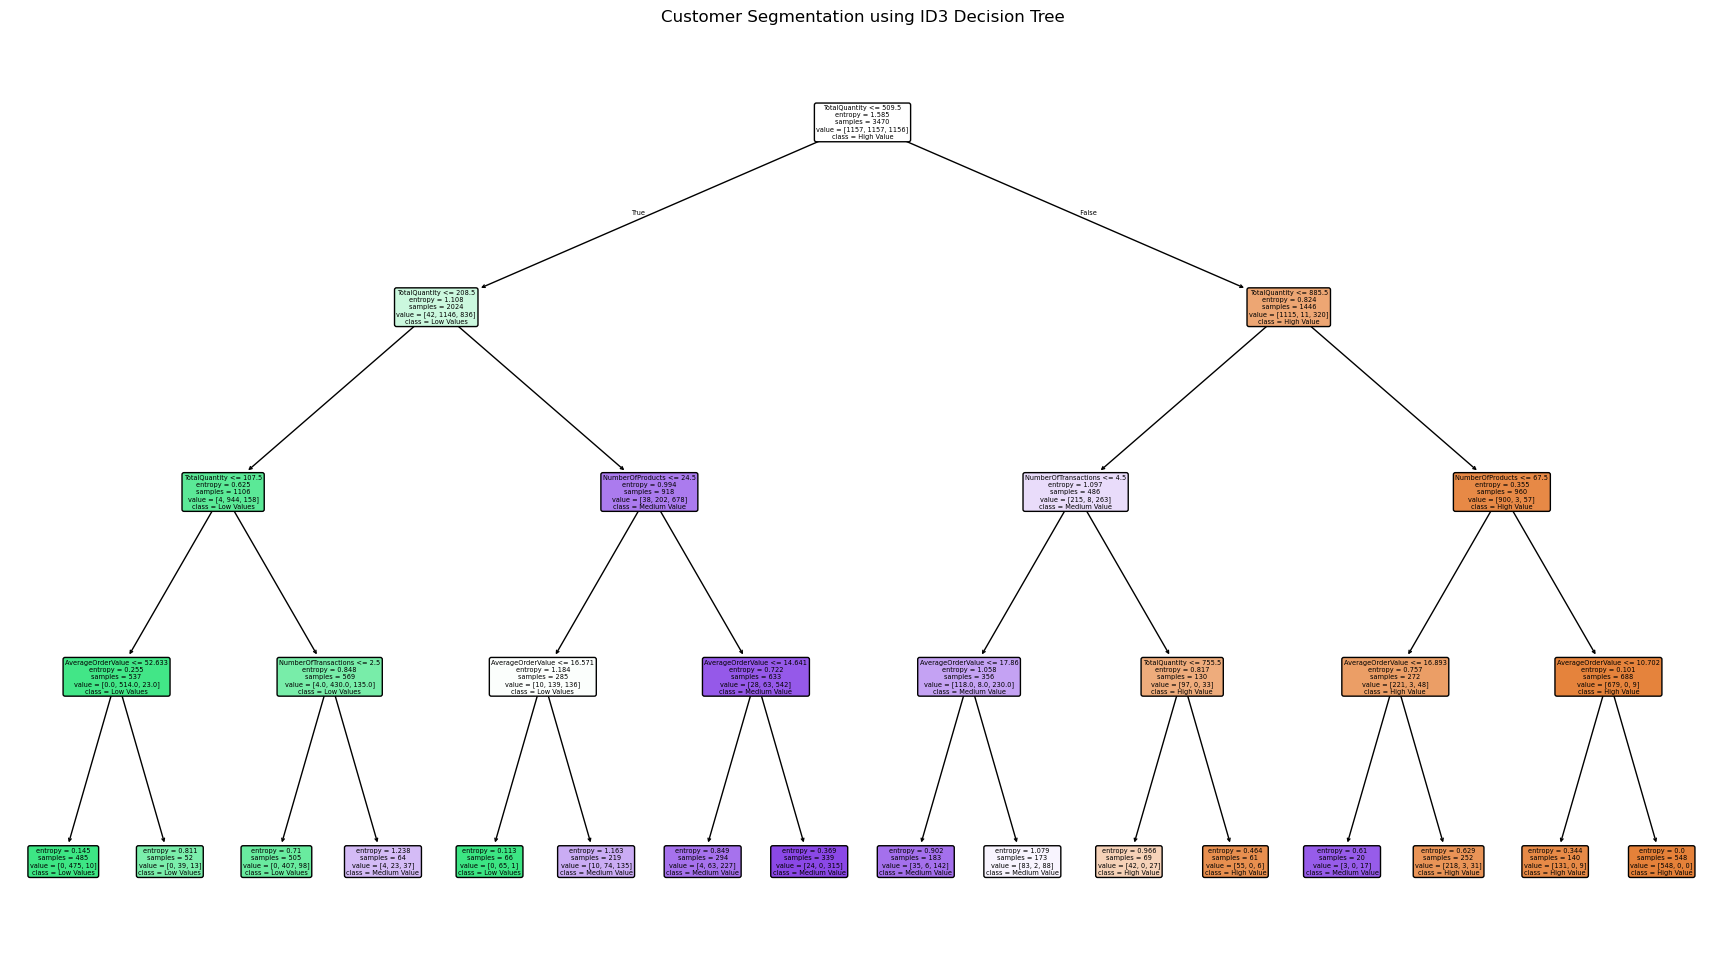

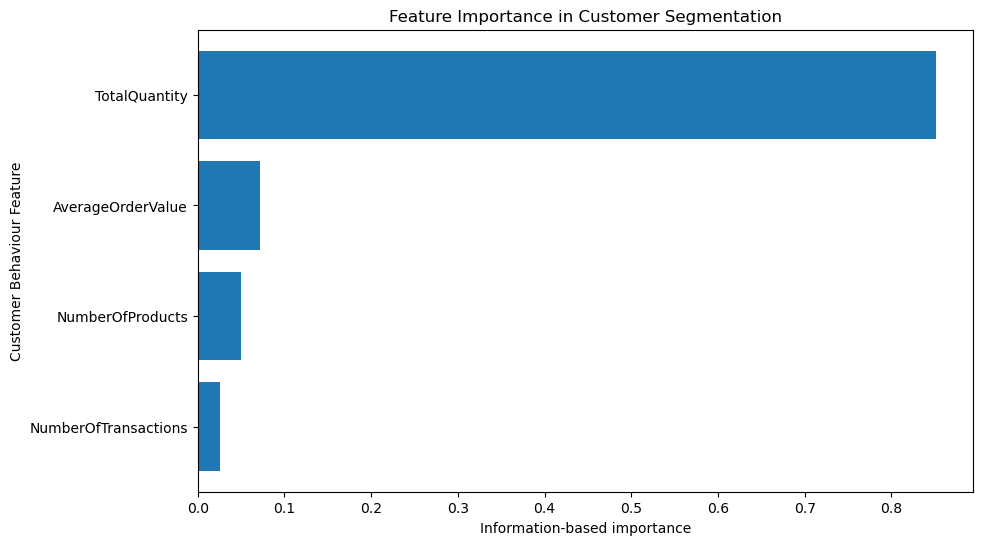

In [91]:
# Get Features importance from the trained decision tree
importance = pd.DataFrame({
    "Features": features,
    "Importance": id3_model.feature_importances_
})

#sort by importance
importance_sorted = importance.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(22,12))

plot_tree(
    id3_model,
    feature_names = features,
    class_names = id3_model.classes_,
    filled = True,
    rounded = True,
    proportion = False
)

plt.title("Customer Segmentation using ID3 Decision Tree")
plt.show()

#Feature importance
plt.figure(figsize=(10,6))

importance_sorted = importance.sort_values(
    "Importance",
    ascending=True
)

plt.barh(
    importance_sorted["Features"],
    importance_sorted["Importance"]
)

plt.xlabel("Information-based importance")
plt.ylabel("Customer Behaviour Feature")
plt.title("Feature Importance in Customer Segmentation")

plt.show()